# Task 5: Ensemble Learning, Model Optimization & Real-World ML Pipeline

### 1. Importing Necessary Libraries

In [18]:
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns            # For statistical data visualization

from sklearn.datasets import load_breast_cancer                     # For loading the Breast Cancer dataset
from sklearn.model_selection import train_test_split, GridSearchCV  # For splitting the dataset and hyperparameter tuning
from sklearn.preprocessing import StandardScaler                    # For feature scaling
from sklearn.linear_model import LogisticRegression                 # For logistic regression baseline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # For ensemble models
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)  # For model evaluation metrics

import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

### 2. Loading Dataset

In [19]:
data = load_breast_cancer()                                # Load the Breast Cancer dataset
X = pd.DataFrame(data.data, columns=data.feature_names)    # Features
y = pd.Series(data.target, name="target")                  # Target: 0 = Malignant, 1 = Benign
df = pd.concat([X, y], axis=1)                              # Combine features and target for EDA
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 3. Exploratory Data Analysis

In [20]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [21]:
print("Missing values in the dataset:", df.isnull().sum().sum())

Missing values in the dataset: 0


In [22]:
# Class distribution to check for imbalance
print("Class distribution (0 = Malignant, 1 = Benign):")
display(y.value_counts())
print("\nClass distribution (%):")
display(y.value_counts(normalize=True) * 100)

Class distribution (0 = Malignant, 1 = Benign):


target
1    357
0    212
Name: count, dtype: int64


Class distribution (%):


target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

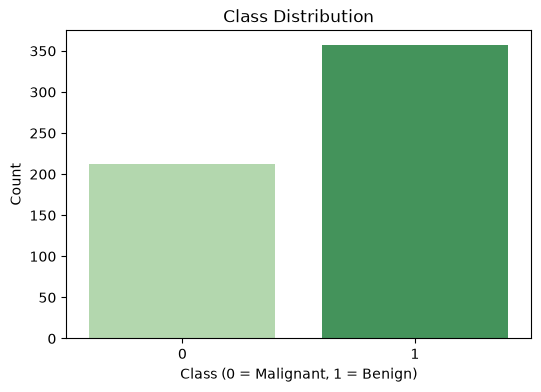

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="Greens")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

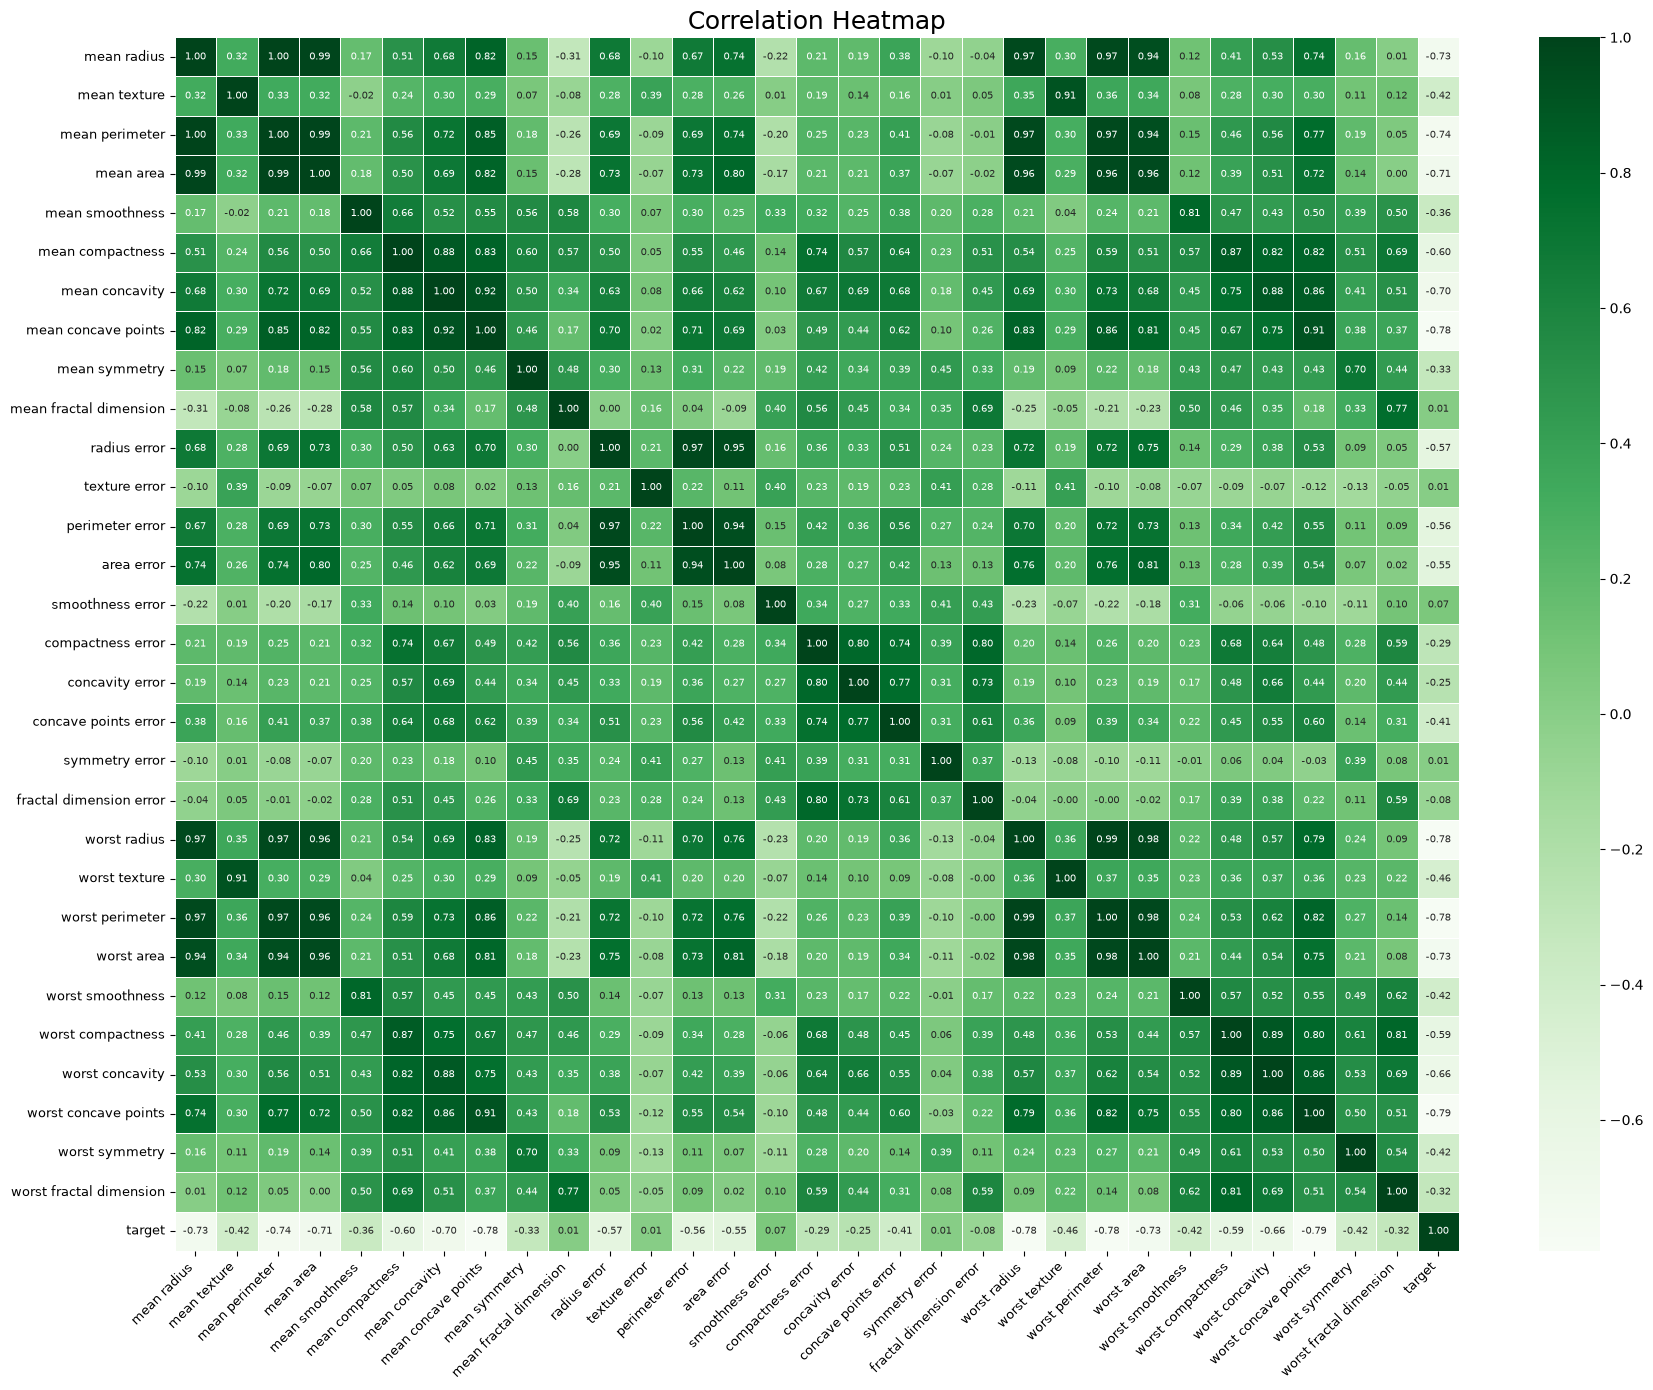

In [24]:
plt.figure(figsize=(18, 14))
corr = df.corr()
sns.heatmap(
    corr,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 4. Pre-Processing

In [25]:
# Train-Test split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Model Training (Baseline + Ensemble Models)

In [27]:
# Define all classification models to be trained and evaluated
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train each model and store the trained model, its predictions, and probabilities
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)                  # All models trained on scaled features for consistency
    trained_models[name] = {
        "model": model,
        "y_pred": model.predict(X_test_scaled),
        "y_prob": model.predict_proba(X_test_scaled)[:, 1]
    }

print("\nModel training completed.")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

Model training completed.


### 6. Evaluation


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Classification Report - Random Forest:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Classification Report - Gradient Boosting:
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       11

,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9939


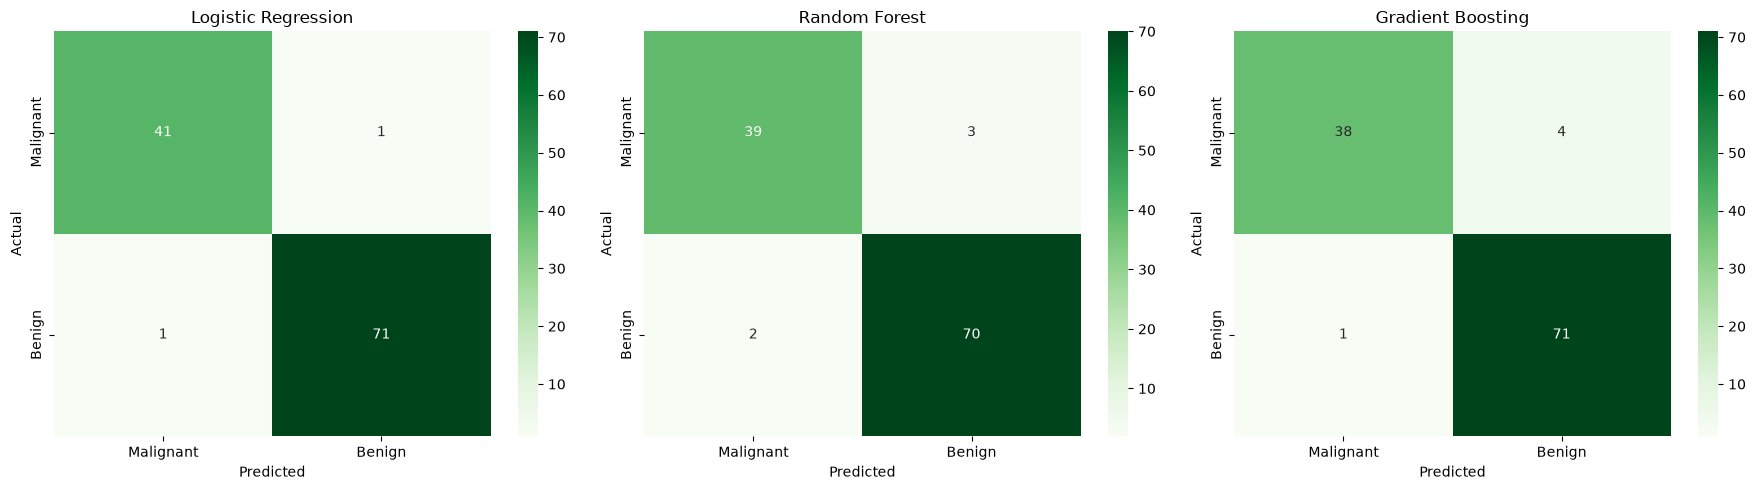

In [28]:
# Evaluate each trained model: metrics table + classification reports + confusion matrix subplots
results = {}
for name, res in trained_models.items():
    y_pred = res["y_pred"]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, res["y_prob"])
    }
    print(f"\nClassification Report - {name}:")
    print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

results_df = pd.DataFrame(results).T.round(4).sort_values(by="F1-Score", ascending=False)
print("\nModel Evaluation Results (Baseline vs Ensemble):")
display(results_df)

# Confusion matrices for all models in a single row of subplots
fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
for ax, (name, res) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Malignant", "Benign"],
                yticklabels=["Malignant", "Benign"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=500)  # Save the confusion matrices figure
plt.show()

### 7. ROC Curve & AUC Score

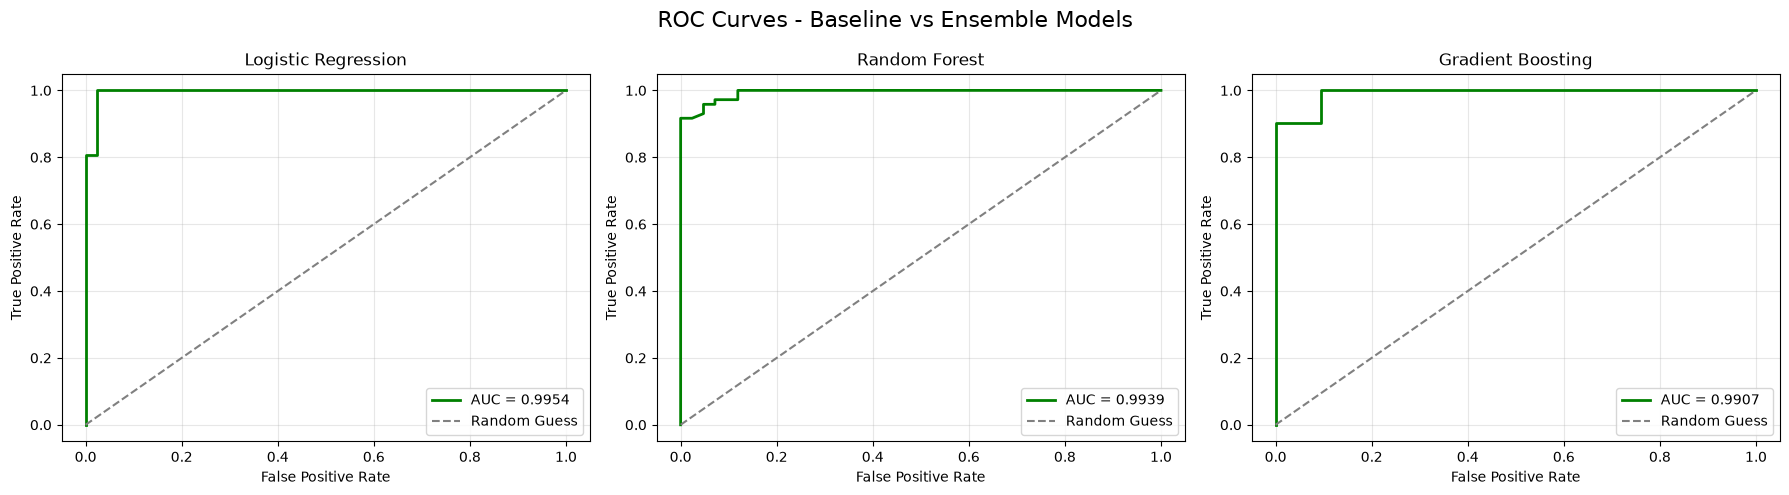

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, trained_models.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = roc_auc_score(y_test, res["y_prob"])

    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}", color="green")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")

    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("ROC Curves - Baseline vs Ensemble Models", fontsize=16)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=500)  # Save the ROC curves figure
plt.show()

### 8. Overfitting Check (Ensemble Stability)

In [30]:
overfit_check = {}
for name, res in trained_models.items():
    model = res["model"]
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, res["y_pred"])
    overfit_check[name] = {
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Gap (Train - Test)": round(train_acc - test_acc, 4)
    }

overfit_df = pd.DataFrame(overfit_check).T.sort_values(by="Gap (Train - Test)", ascending=False)
print("Overfitting Check (large gap = overfitting):")
display(overfit_df)

Overfitting Check (large gap = overfitting):


,Train Accuracy,Test Accuracy,Gap (Train - Test)
Random Forest,1.000,0.9561,0.0439
Gradient Boosting,1.000,0.9561,0.0439
Logistic Regression,0.989,0.9825,0.0066


**Why ensembles reduce overfitting:** Random Forest averages predictions across many de-correlated trees (bagging), which cancels out individual trees' noise and lowers variance. Gradient Boosting builds trees sequentially to correct prior errors, which improves bias but needs tuning (learning rate, depth, number of estimators) to avoid overfitting — this motivates the hyperparameter tuning step below.

### 9. Hyperparameter Tuning (GridSearchCV)

In [31]:
# Hyperparameter tuning for Random Forest using GridSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print(f"Best CV F1-Score: {grid.best_score_:.4f}")

Best Parameters: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1-Score: 0.9685


In [32]:
best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
y_prob_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Classification Report - Tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned, target_names=["Malignant", "Benign"]))

Classification Report - Tuned Random Forest:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 10. Final Model Comparison (Baseline vs Ensemble vs Tuned)

Final Model Comparison:


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9939
Random Forest (Tuned),0.9474,0.9583,0.9583,0.9583,0.9947


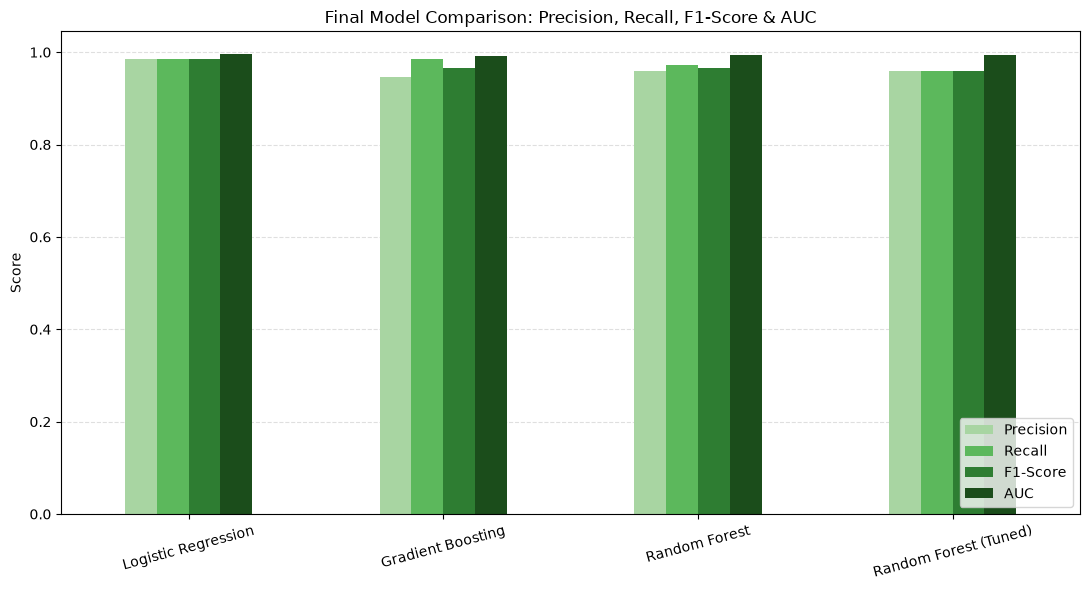

In [33]:
results["Random Forest (Tuned)"] = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-Score": f1_score(y_test, y_pred_tuned),
    "AUC": roc_auc_score(y_test, y_prob_tuned)
}

final_df = pd.DataFrame(results).T.round(4).sort_values(by="F1-Score", ascending=False)
print("Final Model Comparison:")
display(final_df)

final_df[["Precision", "Recall", "F1-Score", "AUC"]].plot(
    kind="bar", figsize=(11, 6), color=["#a8d5a2", "#5cb85c", "#2e7d32", "#1b4d1b"]
)
plt.title("Final Model Comparison: Precision, Recall, F1-Score & AUC")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

### 11. Feature Importance (Model Interpretation)

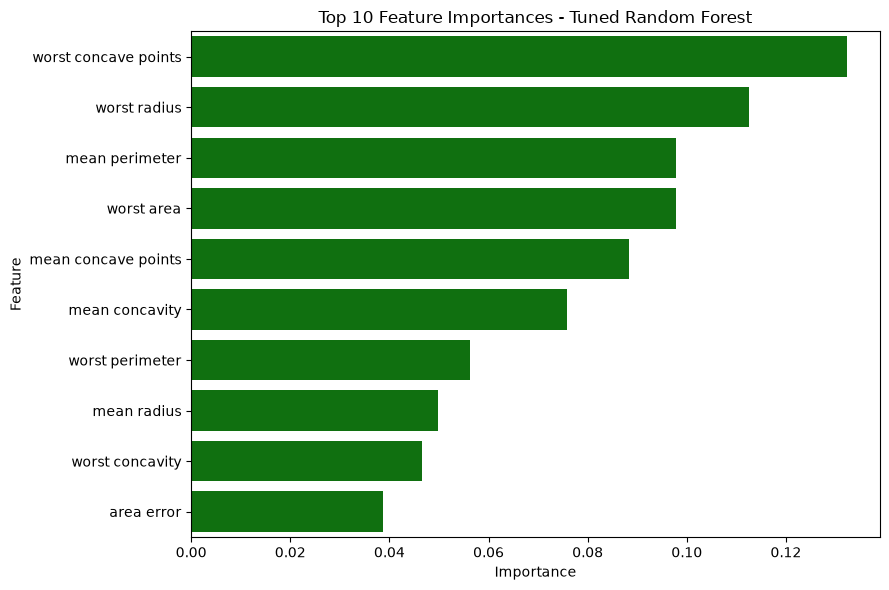

In [34]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="green")
plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Final Model Selection Justification

**Performance:** Logistic Regression achieved the best overall test performance among the evaluated models. It obtained the highest Accuracy (0.9825), Precision (0.9861), Recall (0.9861), F1-Score (0.9861), and AUC (0.9954). Although Gradient Boosting and Random Forest also performed well, neither surpassed Logistic Regression on any of the reported evaluation metrics.

**Comparison with Ensemble Models:** The ensemble models successfully captured the non-linear patterns in the dataset and achieved strong performance. Gradient Boosting obtained an F1-Score of 0.9660 and AUC of 0.9907, while Random Forest achieved an F1-Score of 0.9655 and AUC of 0.9939. However, these results were still below Logistic Regression, indicating that the additional model complexity did not provide a performance advantage for this dataset.

**Effect of Tuning:** GridSearchCV was applied to Random Forest using 5-fold cross-validation with F1-Score as the optimization metric. The tuning process systematically searched different combinations of `n_estimators`, `max_depth`, and `min_samples_split` rather than relying on manually selected parameters. However, the tuned Random Forest achieved lower test Accuracy (0.9474) and F1-Score (0.9583) than the untuned Random Forest, which achieved 0.9561 Accuracy and 0.9655 F1-Score. Its AUC also increased only slightly from 0.9939 to 0.9947, remaining below Logistic Regression's 0.9954.

**Stability and Generalization:** The final model should not be selected solely based on model complexity or the use of ensemble techniques. The test results indicate that Logistic Regression generalizes particularly well on this dataset, achieving consistently high values across all evaluation metrics. Its strong performance suggests that the relationship between the selected features and the target can be effectively captured by a linear decision boundary.

**Interpretability:** Logistic Regression also provides strong interpretability through its coefficients, allowing the contribution and direction of individual features to be examined. While Random Forest and Gradient Boosting provide feature importance measures, their additional complexity is not justified here because they do not improve predictive performance over Logistic Regression.

**Final Model Selected: Logistic Regression.** It achieved the highest Accuracy (98.25%), Precision (98.61%), Recall (98.61%), F1-Score (98.61%), and AUC (99.54%) among all evaluated models. Therefore, Logistic Regression provides the best combination of predictive performance, generalization, simplicity, and interpretability for this classification task. The ensemble models remain strong alternatives, but their additional complexity does not result in better performance on this dataset.
